<a href="https://colab.research.google.com/github/Cato-8/Customer-Churn-Analysis/blob/main/Lab5_%3CMarvi_Malik%3E_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LAB 05 — Linear Regression: Predicting House Prices

## Student Information
**Name:Marvi Malik**
**Student ID:023-24-0016**
**Section:B**
**GitHub:**
**Kaggle:**
**Dataset:** House Prices — Advanced Regression Techniques
**Dataset Source:** Kaggle — https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, Pandas, and Linear Regression theory. Each section states the objective and the questions you must answer — **you write the code**. Every table, plot, and metric needs a short written observation.
>
> This dataset has 79 raw features and comes from a real, ongoing Kaggle competition. Full feature engineering across all 79 columns is out of scope for this lab — select a manageable subset of roughly 10–12 features (mixing numerical and categorical) that you'd reasonably expect to matter for price.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [ ]:
# YOUR CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


---

## 1. Problem Definition

Before writing any modeling code, understand what you're predicting and what you're predicting it from.

**Tasks**
1. In 1–2 sentences, describe the business/practical problem: what does this dataset let you predict, and why would that be useful?
2. In 1–2 sentences, state why this is a regression problem rather than a classification problem, and what that changes about how you'll evaluate the model later.

**Answer 1:**
_(this problem requires us to predict the saleprice value for a property or house based the features it will have.Doing so will help in fair estimating the approximate price needed by a buyer, seller, or bank to collect it or approve loan etc)_

**Answer 2:**
_(because it is predicting a continuous numerical value as output, Not a class is defined already for predicting. this will change evaluation way instead of accuracy/prediction, F1 Score, etc MSE, RMSE etc matrix will be used here.)_

---

## 2. Dataset Exploration

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.info()`, `df.head()`, `df.describe()`

**Task**
3. Load `train.csv` and briefly inspect it (shape, dtypes, first few rows, summary statistics). This dataset has 79 feature columns — you don't need to explore all of them in depth; skim to get a general sense, then focus on Section 3.

In [ ]:
# Task 3 — load and inspect the dataset
df = pd.read_csv("/content/train.csv")
df.shape
df.info()
df.head()
df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


**Observations:**
_(what did you notice about the data — size, ranges, any obvious oddities?

The dataset contains 1460 rows and 81 columns, mixing 38 numerical and 43 categorical (object) features. SalePrice ranges from $34,900 to $755,000, with a mean around $180,921 and a fairly wide spread (std ~$79,442), suggesting some high-value outlier houses. Several columns have significant missing values, PoolQC, MiscFeature, and Alley are missing in over 90% of rows , while others like LotArea show large gaps between the median and max, hinting at a few unusually large lots.)_

---

## 3. Feature and Target Identification

**Task**
4. Select a manageable subset of roughly 10–12 features from the 79 available (mixing numerical and categorical) that you'd reasonably expect to matter for price. Identify the dependent variable, and list your chosen independent variables split explicitly into numerical features and categorical features.

**Answer 4:**

Dependent variable: SalePrice

Numerical independent variables: OverallQual,GrLiveArea,TotalBsmtSF,GarageCars,YearBuilt,FullBath,TotRmsAbvGrd

Categorical independent variables: Neighbourhood,HouseStyle,KitchenQual,ExterQual

---

## 4. Data Preparation

scikit-learn's `LinearRegression` requires fully numeric input. Convert categorical columns appropriately.

*Concepts/functions you may find useful:* `df[col].map({'yes': 1, 'no': 0})`, `pd.get_dummies(df, columns=[...])`

**Tasks**
5. Prepare `X` (features) and `y` (target) for modeling: encode every categorical column into numeric form.
6. Briefly justify your choice of encoding method for each type of column.
7. Confirm `X` is fully numeric with no missing values.

In [ ]:
# Task 5 — define X and y, encode categorical columns
features = ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageCars', 'YearBuilt',
            'FullBath', 'TotRmsAbvGrd', 'Neighborhood', 'HouseStyle', 'KitchenQual', 'ExterQual']
X = df[features]
y = df['SalePrice']
print(X.shape)
print(y.shape)
X = pd.get_dummies(X, columns=['Neighborhood', 'HouseStyle', 'KitchenQual', 'ExterQual'])
df['KitchenQual'].unique()
df['ExterQual'].unique()


(1460, 11)
(1460,)


array(['Gd', 'TA', 'Ex', 'Fa'], dtype=object)

In [ ]:
# Task 7 — confirm X is fully numeric with no missing values
# X.info()
X.shape
# X.isna().sum()

(1460, 48)

**Answer 6 (encoding justification):**
_(Numerical features (OverallQual, GrLivArea, TotalBsmtSF, etc.) needed no encoding since they're already numeric. For categorical features, I used one-hot encoding (pd.get_dummies) for Neighborhood and HouseStyle since these have no natural order — one location isn't "greater than" another. I also one-hot encoded KitchenQual and ExterQual, even though these are ordinal (Ex > Gd > TA > Fa) — an ordinal integer mapping would have preserved that order more efficiently with fewer columns, but one-hot encoding still works correctly since Linear Regression can learn separate coefficients for each category.)_

---

## 5. Train/Test Split

*Concepts/functions you may find useful:* `train_test_split(X, y, test_size=..., random_state=...)`

**Task**
8. Split `X` and `y` into training and test sets (e.g. an 80/20 split) and report the resulting shapes.

In [ ]:
# Task 8 — train/test split, report shapes
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(1168, 48) (292, 48) (1168,) (292,)


---

## 6. Linear Regression Model

*Concepts/functions you may find useful:* `LinearRegression()`, `.fit(X_train, y_train)`

**Task**
9. Train a `LinearRegression` model on the training data.

In [ ]:
# Task 9 — train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)



LinearRegression()

---

## 7. Predictions

*Concepts/functions you may find useful:* `.predict(X)`

**Task**
10. Generate predicted prices on the test set, and display a small table comparing actual vs. predicted price for 10 test houses.

In [ ]:
# Task 10 — generate predictions, compare actual vs predicted
y_pred = model.predict(X_test)

comparison = pd.DataFrame({'Actual Price': y_test.values, 'Predicted Price': y_pred})
comparison.head(10)


,Actual Price,Predicted Price
0,154500,137821.836713
1,325000,322785.627008
2,115000,112728.036105
3,159000,172269.722059
4,315500,304661.901104
5,75500,66183.309235
6,311500,232359.049203
7,146000,147457.922082
8,84500,65732.774824
9,135500,118808.064555


**Task 10 — Actual vs. Predicted (sample of 10)**

| Actual Price | Predicted Price |
|---|---|
|154500 |137821.83 |
|325000 |322785.62 |
|115000|112728.036 |
|159000|172269.72|
|315500|66183.30|
|75500|66183.30|
|311500|232359.049|
|146000|65732.77|
|84500|65732.77|
|135500|118808.064|

---

## 8. Coefficients and Intercept

*Concepts/functions you may find useful:* `model.intercept_`, `model.coef_`, `pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})`

**Tasks**
11. Extract the intercept and all coefficients. Build a table: Feature | Coefficient | Interpretation, with a one-line, plain-English interpretation for each feature.
12. Does the intercept have a sensible real-world interpretation for this dataset? Why or why not?

In [ ]:
# Task 11 — extract intercept and coefficients
print("Intercept",model.intercept_)
print(model.coef_)
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
coefficients



Intercept -440630.6661061469
[ 1.25824271e+04  5.36116602e+01  4.94125437e+00  1.10748959e+04
  2.25267205e+02 -1.06996295e+03  1.11575927e+03 -2.45931917e+04
 -2.39351188e+04 -2.71848909e+04 -2.86715286e+03  3.00886793e+04
  4.31857020e+02  2.08015881e+04 -2.12016315e+04 -1.34311125e+03
 -1.31773344e+04 -2.09483286e+04 -9.95614688e+03 -1.05499775e+04
 -1.48107935e+04 -8.44576830e+03  5.50756935e+04  3.06146420e+04
 -2.04680245e+04 -1.70794482e+04 -8.50360421e+03 -9.01026172e+03
  7.27811499e+03  4.08679099e+04  1.28889196e+04  3.60273805e+04
 -6.48057481e+02 -2.26315336e+03  9.73770587e+03 -2.16344325e+03
 -1.55664206e+04 -8.61202796e+03  1.37052310e+04  5.81016572e+03
  3.13325224e+04 -1.30273543e+04 -4.08537953e+03 -1.42197885e+04
  2.06646367e+04 -8.56446478e+03 -6.65474471e+03 -5.44542717e+03]


,Feature,Coefficient
0,OverallQual,12582.427102
1,GrLivArea,53.611660
2,TotalBsmtSF,4.941254
3,GarageCars,11074.895854
4,YearBuilt,225.267205
5,FullBath,-1069.962953
6,TotRmsAbvGrd,1115.759268
7,Neighborhood_Blmngtn,-24593.191736
8,Neighborhood_Blueste,-23935.118778
9,Neighborhood_BrDale,-27184.890940


**Task 11 — Coefficient Table**

| Feature | Coefficient | Interpretation |
|---|---|---|
| OverallQual | 12582.43 | Each 1-point increase in overall quality raises price by ~$12,582, holding other features constant |
| GrLivArea | 53.61 | Each additional sq ft of living area raises price by ~$53.61 |
| TotalBsmtSF | 4.94 | Each additional sq ft of basement area raises price by ~$4.94 |
| GarageCars | 11074.90 | Each extra garage car capacity raises price by ~$11,075 |
| YearBuilt | 225.27 | Each year newer the house is built raises price by ~$225 |
| FullBath | -1069.96 | Each additional full bathroom lowers price by ~$1,070 (likely overlaps with GrLivArea's effect) |
| TotRmsAbvGrd | 1115.76 | Each additional room above grade raises price by ~$1,116 |
| Neighborhood_Blmngtn | -24593.19 | Being in Bloomington Heights lowers price by ~$24,593 vs. baseline |
| Neighborhood_Blueste | -23935.12 | Being in Bluestem lowers price by ~$23,935 |
| Neighborhood_BrDale | -27184.89 | Being in Briardale lowers price by ~$27,185 |
| Neighborhood_BrkSide | -2867.15 | Being in Brookside lowers price by ~$2,867 |
| Neighborhood_ClearCr | 30088.68 | Being in Clear Creek raises price by ~$30,089 |
| Neighborhood_CollgCr | 431.86 | Being in College Creek raises price by ~$432 |
| Neighborhood_Crawfor | 20801.59 | Being in Crawford raises price by ~$20,802 |
| Neighborhood_Edwards | -21201.63 | Being in Edwards lowers price by ~$21,202 |
| Neighborhood_Gilbert | -1343.11 | Being in Gilbert lowers price by ~$1,343 |
| Neighborhood_IDOTRR | -13177.33 | Being in IDOTRR lowers price by ~$13,177 |
| Neighborhood_MeadowV | -20948.33 | Being in Meadow Village lowers price by ~$20,948 |
| Neighborhood_Mitchel | -9956.15 | Being in Mitchell lowers price by ~$9,956 |
| Neighborhood_NAmes | -10549.98 | Being in North Ames lowers price by ~$10,550 |
| Neighborhood_NPkVill | -14810.79 | Being in Northpark Villa lowers price by ~$14,811 |
| Neighborhood_NWAmes | -8445.77 | Being in Northwest Ames lowers price by ~$8,446 |
| Neighborhood_NoRidge | 55075.69 | Being in Northridge raises price by ~$55,076 |
| Neighborhood_NridgHt | 30614.64 | Being in Northridge Heights raises price by ~$30,615 |
| Neighborhood_OldTown | -20468.02 | Being in Old Town lowers price by ~$20,468 |
| Neighborhood_SWISU | -17079.45 | Being in SWISU lowers price by ~$17,079 |
| Neighborhood_Sawyer | -8503.60 | Being in Sawyer lowers price by ~$8,504 |
| Neighborhood_SawyerW | -9010.26 | Being in Sawyer West lowers price by ~$9,010 |
| Neighborhood_Somerst | 7278.11 | Being in Somerset raises price by ~$7,278 |
| Neighborhood_StoneBr | 40867.91 | Being in Stone Brook raises price by ~$40,868 |
| Neighborhood_Timber | 12888.92 | Being in Timberland raises price by ~$12,889 |
| Neighborhood_Veenker | 36027.38 | Being in Veenker raises price by ~$36,027 |
| HouseStyle_1.5Fin | -648.06 | 1.5-story finished style lowers price by ~$648 |
| HouseStyle_1.5Unf | -2263.15 | 1.5-story unfinished style lowers price by ~$2,263 |
| HouseStyle_1Story | 9737.71 | 1-story style raises price by ~$9,738 |
| HouseStyle_2.5Fin | -2163.44 | 2.5-story finished style lowers price by ~$2,163 |
| HouseStyle_2.5Unf | -15566.42 | 2.5-story unfinished style lowers price by ~$15,566 |
| HouseStyle_2Story | -8612.03 | 2-story style lowers price by ~$8,612 |
| HouseStyle_SFoyer | 13705.23 | Split foyer style raises price by ~$13,705 |
| HouseStyle_SLvl | 5810.17 | Split level style raises price by ~$5,810 |
| KitchenQual_Ex | 31332.52 | Excellent kitchen quality raises price by ~$31,333 |
| KitchenQual_Fa | -13027.35 | Fair kitchen quality lowers price by ~$13,027 |
| KitchenQual_Gd | -4085.38 | Good kitchen quality lowers price by ~$4,085 |
| KitchenQual_TA | -14219.79 | Typical/Average kitchen quality lowers price by ~$14,220 |
| ExterQual_Ex | 20664.64 | Excellent exterior quality raises price by ~$20,665 |
| ExterQual_Fa | -8564.46 | Fair exterior quality lowers price by ~$8,564 |
| ExterQual_Gd | -6654.74 | Good exterior quality lowers price by ~$6,655 |
| ExterQual_TA | -5445.43 | Typical/Average exterior quality lowers price by ~$5,445 |

**Answer 12:**
_(The intercept (-$440,630.67) does not have a sensible real-world interpretation here. It represents the predicted price when every single feature is zero — 0 overall quality, 0 sq ft living area, 0 sq ft basement, built in year 0, etc. — which describes a house that cannot actually exist. So the intercept is just a mathematical anchor point needed for the regression equation to work, not a meaningful real-world baseline price.)_

---

## 9. Residual Analysis

*Concepts/functions you may find useful:* `residuals = y_test - y_pred`, `plt.scatter(y_pred, residuals)`, `plt.hist(residuals, bins=...)`

**Task**
13. Compute residuals on the test set and plot them (e.g. residuals vs. predicted values, and a histogram of residuals). Do the residuals look randomly scattered, or is there a visible pattern?

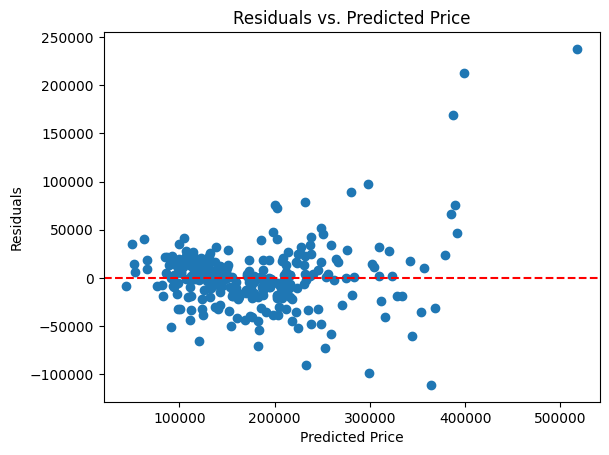

In [ ]:
# Task 13 — compute and plot residuals
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predicted Price")
plt.show()



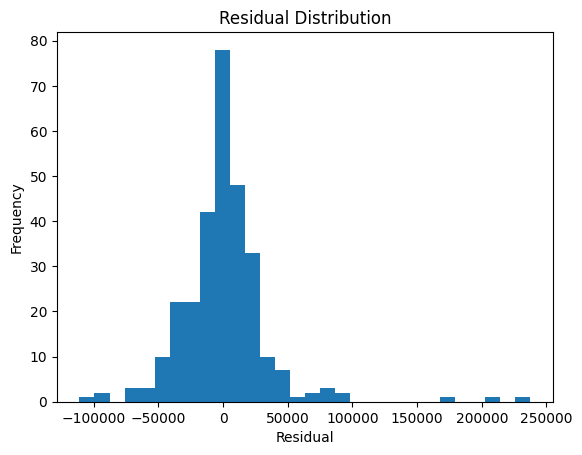

In [ ]:
plt.hist(residuals, bins=30)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

**Answer 13:**
_(Residuals aren't fully random, they cluster tightly around 0 for lower predicted prices, but several large positive outliers appear at higher predicted prices $300,000+, meaning the model underestimates expensive houses. This mild funnel shape suggests the model struggles with non-linear, high-end pricing effects.)_

## 10. Regression Metrics

*Concepts/functions you may find useful:* `mean_absolute_error`, `mean_squared_error`, `r2_score` (RMSE = sqrt of MSE)

**Tasks**
14. Compute MAE, MSE, RMSE, and R² on the test set. Report them in a small table.
15. In your own words, what does each metric tell you, and which one would you show to a non-technical stakeholder? Why?

In [ ]:
# Task 14 — compute MAE, MSE, RMSE, R² on the test set
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 21114.042699318397
MSE: 1178606507.094811
RMSE: 34330.83900947967
R²: 0.8463420622201893


**Task 14 — Test Set Metrics**

| Metric | Value |
|---|---|
| MAE |21114.04 |
| MSE |1178606507.09 |
| RMSE |34330.83 |
| R² |0.846 |

**Answer 15:**
_(MAE tells us the average absolute prediction error in dollars 21,114 off on average, easy to interpret directly. MSE squares the errors, penalizing large mistakes more heavily, but its units (dollars²) aren't intuitive. RMSE brings that back to dollar units $34,331, so it's more interpretable than MSE while still punishing big errors more than MAE. R² tells us what fraction of the price variation the model explains (84.6% here), useful for judging overall model quality but doesn't say how big the errors are in)_

---

## 11. Training vs Testing Performance

*Concepts/functions you may find useful:* `model.predict(X_train)`, comparing metrics computed on train vs. test

**Tasks**
16. Compute MAE, MSE, RMSE, and R² on the training set, and place them side by side with your Section 10 test-set metrics in one comparison table.
17. Is there a large gap between training and testing performance? What would a large gap suggest about overfitting or generalization, and what does your actual result suggest here?

In [ ]:
# Task 16 — compute training-set metrics
y_train_pred = model.predict(X_train)
mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_train_pred)

print("MAE (train):", mae_train)
print("MSE (train):", mse_train)
print("RMSE (train):", rmse_train)
print("R² (train):", r2_train)


MAE (train): 20466.407337301836
MSE (train): 1042496716.4224502
RMSE (train): 32287.717733256562
R² (train): 0.8252178873434944


**Task 16 — Train vs. Test Comparison**

| Metric | Training Set | Test Set |
|---|---|---|
| MAE |21114.04  |20466.407 |
| MSE |1178606507.09 |1042496716.42 |
| RMSE |34330.83  |32287.71 |
| R² |0.846 |0.825|

**Answer 17:**
_(Train and test scores are close — R² is even slightly higher on test (0.85) than train (0.83). This means the model isn't overfitting; it's generalizing well to new data, not just memorizing the training set.)_

---

## 12. Model Interpretation

**Task**
18. Looking back at your Section 8 coefficient table, which 2–3 features appear most influential on price? Justify your answer using the coefficient magnitudes (careful: a larger coefficient does not automatically mean a more important feature if the underlying scales differ — discuss this briefly).

**Answer 18:**
_(Looking at coefficient size alone can be misleading since features have different scales. Using coefficient × typical range, OverallQual, GrLivArea, and Neighborhood (e.g. NoRidge, StoneBr) stand out as the most influential, they combine a meaningful coefficient with a wide real-world range, giving them the biggest actual effect on price. A tiny coefficient like TotalBsmtSF's ($4.94) still matters a lot because basement size varies by thousands of sq ft.)_

---

## 13. Conclusion

**Tasks**
19. Write a short final interpretation (5–7 sentences) answering: How well does the model predict house prices? Which metric is most useful and why? Which feature has the strongest effect? What limitations does Linear Regression have for this dataset? What would you try next?
20. Apply the same feature selection and encoding you used on `train.csv` to `test.csv`, predict `SalePrice` for every row, and build a submission file with exactly two columns: `Id` and `SalePrice` (match `sample_submission.csv`'s format). Save it as `submission.csv`.
21. Submit `submission.csv` on the competition's "Submit Predictions" page. Record your public leaderboard score and rank below.

**Answer 19 — Conclusion:**
_(The Linear Regression model predicts house prices fairly well, with an R² of 0.85 and average error (MAE) of about $21,000. RMSE is most useful for technical evaluation since it penalizes big mistakes, but MAE is easiest to explain to non-technical people. OverallQual and Neighborhood have the strongest effect on price. The main limitation is that Linear Regression assumes straight-line relationships, so it struggles with expensive houses where pricing behaves more non-linearly. Next steps could include trying non-linear models like Random Forest or Gradient Boosting, adding more engineered features, and handling outliers better.)_

In [ ]:
# Task 20 — apply encoding to test.csv, predict SalePrice, build submission.csv
test_df = pd.read_csv("test.csv")

X_new = test_df[features]
X_new = pd.get_dummies(X_new, columns=['Neighborhood', 'HouseStyle', 'KitchenQual', 'ExterQual'])

# align columns with training X
X_new = X_new.reindex(columns=X.columns, fill_value=0)

# handle any missing values in the numeric columns
X_new = X_new.fillna(X_new.median(numeric_only=True))

test_predictions = model.predict(X_new)

submission = pd.DataFrame({
    'Id': test_df['Id'],
    'SalePrice': test_predictions
})
submission.to_csv('submission.csv', index=False)
submission.head()


,Id,SalePrice
0,1461,111530.935025
1,1462,160110.318317
2,1463,161143.023648
3,1464,183850.712198
4,1465,249162.908188


**Answer 21 — Kaggle Leaderboard Result:**

Public score: 0.16618

Rank: 2609

Reflection (1–2 sentences): _(Seeing my model measured against thousands of real submissions (rank 2609) was a humbling but exciting experience. It showed that while my simple 11-feature model performed reasonably, there's clearly room to improve by engineering more features or trying non-linear models to climb the leaderboard.)_

---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, Dataset, Dataset Source)
- [ ] Section 1 — Problem Definition
- [ ] Section 2 — Dataset Exploration
- [ ] Section 3 — Feature and Target Identification
- [ ] Section 4 — Data Preparation (encoding justified)
- [ ] Section 5 — Train/Test Split
- [ ] Section 6 — Linear Regression Model
- [ ] Section 7 — Predictions (actual vs. predicted table)
- [ ] Section 8 — Coefficients and Intercept (full table + interpretation)
- [ ] Section 9 — Residual Analysis (plots + discussion)
- [ ] Section 10 — Regression Metrics (MAE, MSE, RMSE, R²)
- [ ] Section 11 — Training vs Testing Performance (comparison table + discussion)
- [ ] Section 12 — Model Interpretation (most influential features)
- [ ] Section 13 — Conclusion, submission.csv generated, and submitted to the Kaggle competition (score/rank recorded)
- [ ] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted